# Load or Clean Data
If `data/cleaned_df.csv` is found, loads it immediately, which skips the long wait times. On a first time run, fetches file at `data/df.csv` and triggers a **cleaning pipeline** that drops any rows with missing text, splits sentence into individual words, removes stopwords and puntuaction, and uses the **Porter Stemmer** to reduce words to their root form, reducing vocabulary size.

A final "sanity check" is performed after this, including dropping any remaining rows with any field at null, removing rows where final text was blank, and dropping duplicates after this, to avoid data leakage and overepresentation.

In [1]:
import os
import pandas as pd
import numpy as np
import re
from tqdm import tqdm
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

from wordcloud import WordCloud
import matplotlib.pyplot as plt
import seaborn as sns

RAW_CSV_DIR = "data/df.csv"
CLEAN_CSV_DIR = "data/cleaned_df.csv"

# 0 -> ham, 1 -> phish, 2 -> spam
LABELS = {0 : 'ham', 1: 'phish', 2: 'spam'}

# initialize stopwords
stopwords = set(stopwords.words('english'))

# load or create clean data
if os.path.exists(CLEAN_CSV_DIR):
    print(f"Found existing cleaned dataset at {CLEAN_CSV_DIR}. Loading instantly...")
    df = pd.read_csv(CLEAN_CSV_DIR)
    
else:
    print(f"Cleaned dataset not found. Loading raw data from {RAW_CSV_DIR}...")
    df = pd.read_csv(RAW_CSV_DIR)
    df = df.dropna(subset=['text'])
    
    ps = PorterStemmer()
    tqdm.pandas()
    
    def clean_spam_text(text):
        text = re.sub('[^a-zA-Z]', ' ', text)

        words = text.lower().split()

        cleaned_words = []
        for w in words:
            if w in stopwords:
                continue

            cleaned_words.append(ps.stem(w))

        return ' '.join(cleaned_words)

    # this take ~15 min
    df['cleaned_text'] = df['text'].progress_apply(clean_spam_text)
    
    df.to_csv(CLEAN_CSV_DIR, index=False)
    print("Saved successfully!")

df = df.dropna(subset=['cleaned_text', 'label'])
df = df[df['cleaned_text'].astype(str).str.strip() != '']

print(f"Dataset ready! Shape: {df.shape}")

Found existing cleaned dataset at data/cleaned_df.csv. Loading instantly...
Dataset ready! Shape: (365284, 3)


# Perform Exploratory Data Analysis
Below we perform some EDA using methods learned in class. The main objective is to better understand the text data present in the emails, how it relates to the classification problem, and to perform operations that increase its quality and expressiveness.

## Class-based statistics and WordCloud
Perform statistical analysis of the email text present based on the class and plot the WordCloud.

--- Exploratory Data Analysis ---

Examples per class:
Class_Name
Ham         168430
Spam        154011
Phishing     42843
Name: count, dtype: int64


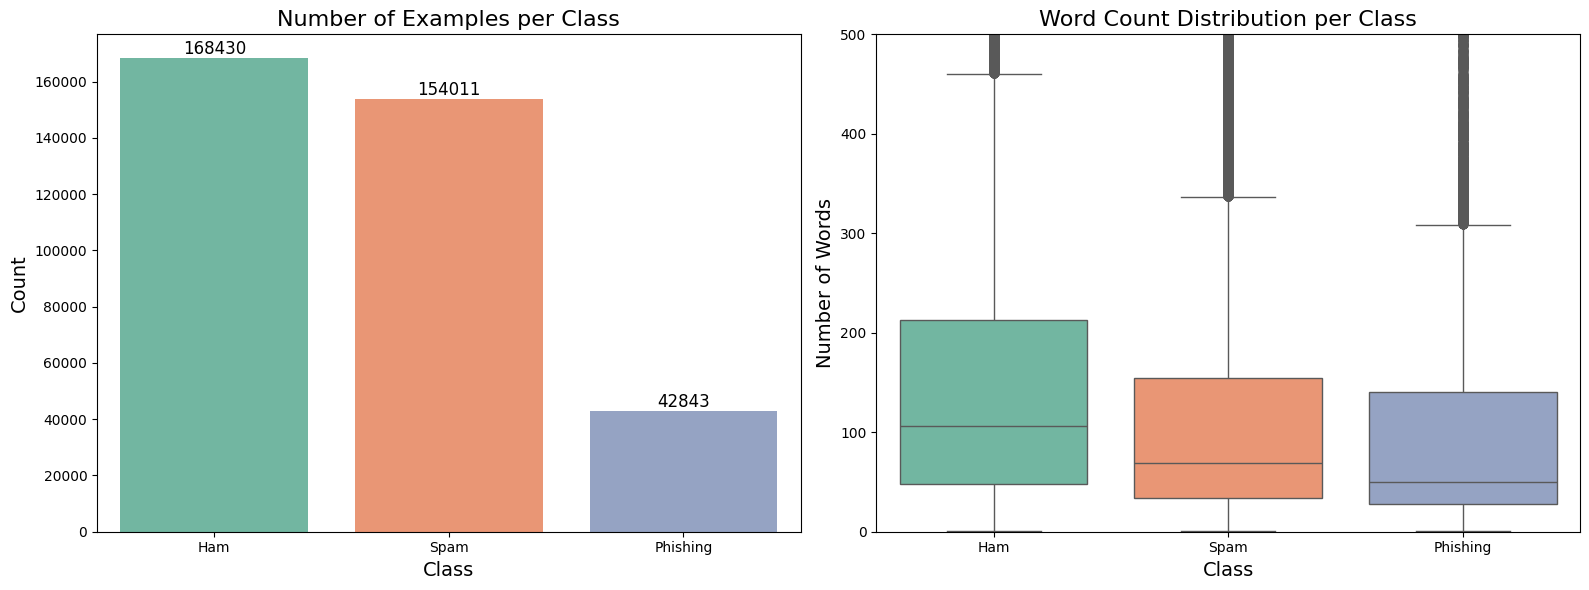

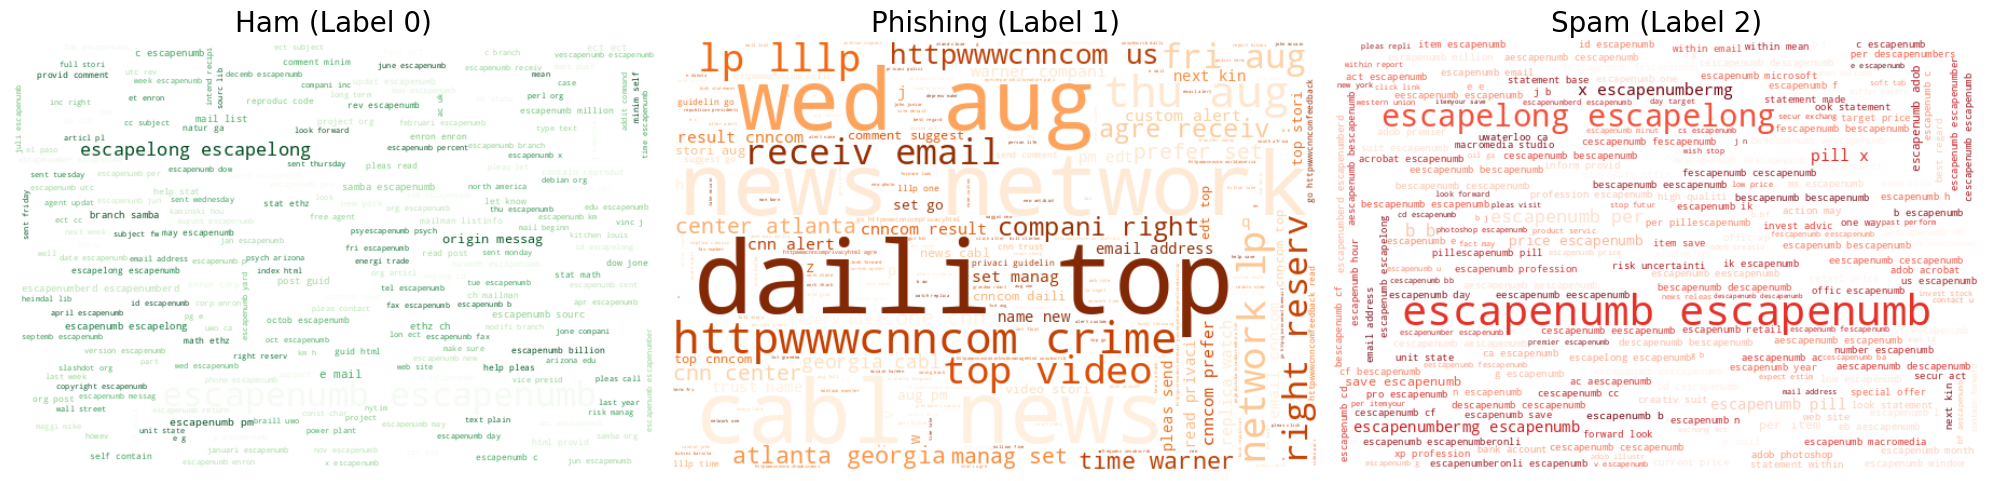

In [2]:
print("--- Exploratory Data Analysis ---")

label_names = {0: 'Ham', 1: 'Phishing', 2: 'Spam'}
df['Class_Name'] = df['label'].map(label_names)

# Calculate exact counts
class_counts = df['Class_Name'].value_counts()
print("\nExamples per class:")
print(class_counts)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- PLOT 1: Class Distribution (Bar Chart) ---
sns.countplot(data=df, x='Class_Name', hue='Class_Name', order=['Ham', 'Spam', 'Phishing'], 
              palette='Set2', ax=axes[0], legend=False)
axes[0].set_title('Number of Examples per Class', fontsize=16)
axes[0].set_xlabel('Class', fontsize=14)
axes[0].set_ylabel('Count', fontsize=14)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', fontsize=12)

# --- PLOT 2: Word Count Distribution (Boxplot) ---
df['word_count'] = df['cleaned_text'].astype(str).apply(lambda x: len(x.split()))

sns.boxplot(data=df, x='Class_Name', hue='Class_Name', y='word_count', order=['Ham', 'Spam', 'Phishing'], 
            palette='Set2', ax=axes[1], legend=False)
axes[1].set_title('Word Count Distribution per Class', fontsize=16)
axes[1].set_xlabel('Class', fontsize=14)
axes[1].set_ylabel('Number of Words', fontsize=14)
axes[1].set_ylim(0, 500) 

plt.tight_layout()
plt.show()

df_ham = df[df['label'] == 0]
df_phish = df[df['label'] == 1]
df_spam = df[df['label'] == 2]

ham_text = " ".join(df_ham['cleaned_text'].astype(str))
phish_text = " ".join(df_phish['cleaned_text'].astype(str))
spam_text = " ".join(df_spam['cleaned_text'].astype(str))

wc_ham = WordCloud(width=600, height=400, background_color='white', 
                   colormap='Greens').generate(ham_text)
wc_phish = WordCloud(width=600, height=400, background_color='white', 
                     colormap='Oranges').generate(phish_text)
wc_spam = WordCloud(width=600, height=400, background_color='white', 
                    colormap='Reds').generate(spam_text)

fig, axs = plt.subplots(1, 3, figsize=(20, 6))

axs[0].imshow(wc_ham, interpolation='bilinear')
axs[0].set_title('Ham (Label 0)', fontsize=20)
axs[0].axis('off')

axs[1].imshow(wc_phish, interpolation='bilinear')
axs[1].set_title('Phishing (Label 1)', fontsize=20)
axs[1].axis('off')

axs[2].imshow(wc_spam, interpolation='bilinear')
axs[2].set_title('Spam (Label 2)', fontsize=20)
axs[2].axis('off')

plt.tight_layout()
plt.show()

## Wordcloud after Stopword removal
Several patterns emerge in the Wordcloud and TF-IDF in progressive removals: we remove dataset artifacts, including placeholders, common non-informative words, single letters, and specific phishing/ham dump artifacts that could be used by the models unjustifiably (due to nature of data) to perform classification.

(364653, 5)
--- Exploratory Data Analysis ---

Examples per class:
Class_Name
Ham         168384
Spam        153427
Phishing     42842
Name: count, dtype: int64


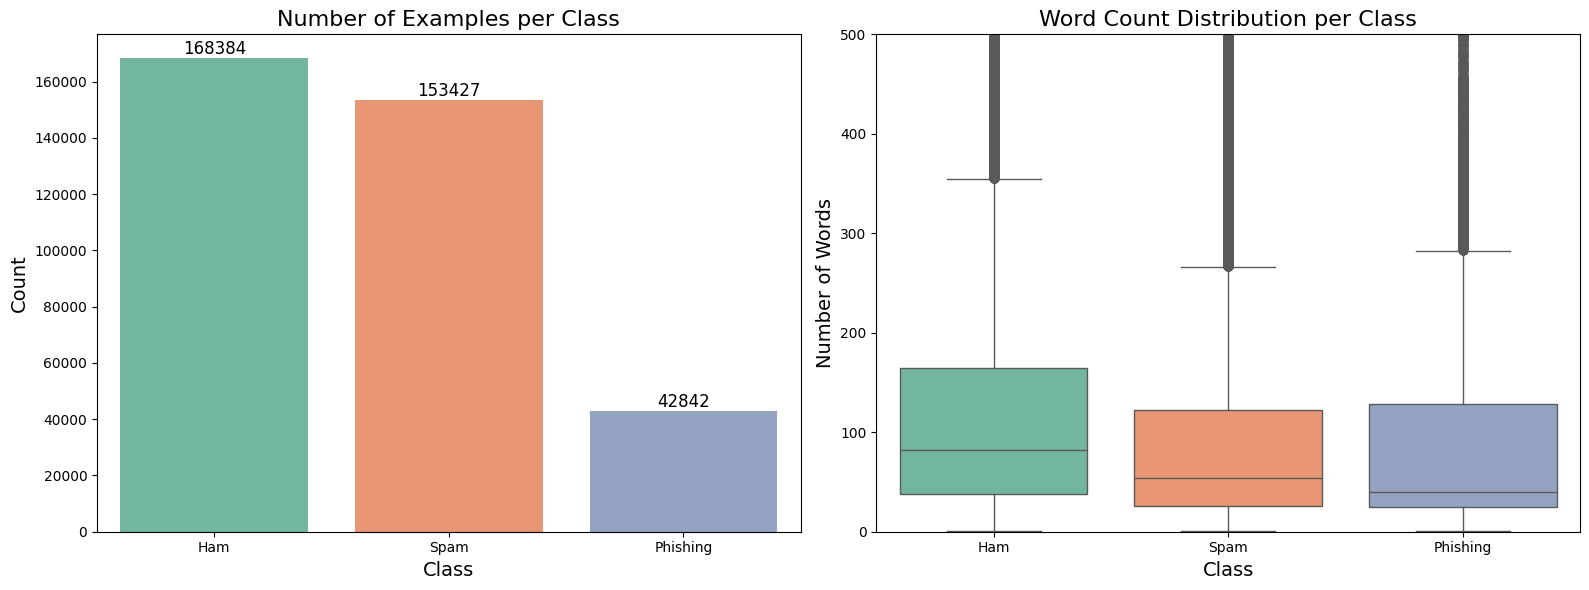

In [3]:
# usually wordclouds removes stopwords but this is after stemming
custom_stopwords = set()
custom_stopwords.update([
    # dataset artifacts
    'cabl', 'news', 'daili', 'fri', 'aug', 'wed', 'thu', 'mon', 'tue',
    'top', 'receiv', 'network', 'email', 
    
    # Stemmed English stop words and extremely common non-informative words
    'thi', 'wa', 'ha', 'hi', 'ani', 'onli', 'use', 'will', 'need', 'know', 'make', 
    'one', 'say', 'look', 'go', 'time', 'pleas', 'thank', 'now', 'want', 'said',
    'new', 'may', 'work', 'inform', 'even', 'get', 'see', 'right', 'also', 'much', 'day', 'year',
    
    # Single or short letter noise
    'b', 'x', 'c', 'e', 'u', 'v', 'p', 'lp', 'co', 'com', 'http', 'www',
    
    # Specific Phishing/Ham dump artifacts (CNN, Enron, etc.)
    'compani', 'atlanta', 'georgia', 'cnncom', 'lllp', 'reserv', 'prefer', 
    'enron', 'ect', 'hou', 'cnn', 'stat', 'ethz', 'ch', 'httpwwwcnncom', 'html'
])

# apply 'escapenumb', 'mailcom' and 'httpwww' filters
df['cleaned_text'] = (
    df['cleaned_text']
    .str.replace(r'\S*(escapelong|escapenumb|mailcom|httpwww)\S*', '', regex=True, flags=re.IGNORECASE)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

# apply filter
def remove_stopwords(text):
    # split string into words, filter them, and join back into a string
    return ' '.join([word.lower() for word in text.split() if word not in custom_stopwords])

df['cleaned_text'] = df['cleaned_text'].apply(remove_stopwords)

# drop rows with empty text on NaN
df = df.dropna(subset=['cleaned_text', 'label'])
df = df[df['cleaned_text'].astype(str).str.strip() != '']

print(df.shape)

df_ham = df[df['label'] == 0]
df_phish = df[df['label'] == 1]
df_spam = df[df['label'] == 2]

ham_text = " ".join(df_ham['cleaned_text'].astype(str))
phish_text = " ".join(df_phish['cleaned_text'].astype(str))
spam_text = " ".join(df_spam['cleaned_text'].astype(str))

print("--- Exploratory Data Analysis ---")

label_names = {0: 'Ham', 1: 'Phishing', 2: 'Spam'}
df['Class_Name'] = df['label'].map(label_names)

# Calculate exact counts
class_counts = df['Class_Name'].value_counts()
print("\nExamples per class:")
print(class_counts)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- PLOT 1: Class Distribution (Bar Chart) ---
sns.countplot(data=df, x='Class_Name', hue='Class_Name', order=['Ham', 'Spam', 'Phishing'], 
              palette='Set2', ax=axes[0], legend=False)
axes[0].set_title('Number of Examples per Class', fontsize=16)
axes[0].set_xlabel('Class', fontsize=14)
axes[0].set_ylabel('Count', fontsize=14)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', fontsize=12)

# --- PLOT 2: Word Count Distribution (Boxplot) ---
df['word_count'] = df['cleaned_text'].astype(str).apply(lambda x: len(x.split()))

sns.boxplot(data=df, x='Class_Name', hue='Class_Name', y='word_count', order=['Ham', 'Spam', 'Phishing'], 
            palette='Set2', ax=axes[1], legend=False)
axes[1].set_title('Word Count Distribution per Class', fontsize=16)
axes[1].set_xlabel('Class', fontsize=14)
axes[1].set_ylabel('Number of Words', fontsize=14)
axes[1].set_ylim(0, 500) 

plt.tight_layout()
plt.show()

wc_ham = WordCloud(width=600, height=400, background_color='white', 
                   colormap='Greens', stopwords=custom_stopwords).generate(ham_text)
wc_phish = WordCloud(width=600, height=400, background_color='white', 
                     colormap='Oranges', stopwords=custom_stopwords).generate(phish_text)
wc_spam = WordCloud(width=600, height=400, background_color='white', 
                    colormap='Reds', stopwords=custom_stopwords).generate(spam_text)

fig, axs = plt.subplots(1, 3, figsize=(20, 6))

axs[0].imshow(wc_ham, interpolation='bilinear')
axs[0].set_title('Ham (Label 0)', fontsize=20)
axs[0].axis('off')

axs[1].imshow(wc_phish, interpolation='bilinear')
axs[1].set_title('Phishing (Label 1)', fontsize=20)
axs[1].axis('off')

axs[2].imshow(wc_spam, interpolation='bilinear')
axs[2].set_title('Spam (Label 2)', fontsize=20)
axs[2].axis('off')

plt.tight_layout()
plt.show()

## Duplicates
Find, analyse and remove duplicates.

In [4]:
print("--- Duplicate Analysis ---")

# Group by class and count duplicated text entries
duplicate_counts = df.groupby('Class_Name')['cleaned_text'].apply(lambda x: x.duplicated().sum())

print("Number of duplicated emails per class:")
print(duplicate_counts)

# Total duplicates in the dataset
total_duplicates = df.duplicated(subset=['Class_Name', 'cleaned_text']).sum()
print(f"\nTotal duplicate rows: {total_duplicates}")

print("--- Most Frequent Duplicates ---")

for label in ['Ham', 'Spam', 'Phishing']:
    print(f"\n--- Top 5 Most Repeated '{label}' Emails ---")
    
    # Filter for the current class
    class_df = df[df['Class_Name'] == label]
    
    # Count the frequencies of each text and show the top 5
    # We use .reset_index() to make it display cleanly
    top_dupes = class_df['cleaned_text'].value_counts().reset_index()
    top_dupes.columns = ['Text', 'Count']
    
    # Print the top 5, truncating the text to 100 characters so it doesn't flood your screen
    for index, row in top_dupes.head(5).iterrows():
        text_preview = str(row['Text'])[:100].replace('\n', ' ')
        print(f"Repeated {row['Count']} times: {text_preview}...")

df = df.drop_duplicates(subset=['cleaned_text', 'label'], keep='first')

--- Duplicate Analysis ---
Number of duplicated emails per class:
Class_Name
Ham         75188
Phishing      202
Spam        75674
Name: cleaned_text, dtype: int64

Total duplicate rows: 151064
--- Most Frequent Duplicates ---

--- Top 5 Most Repeated 'Ham' Emails ---
Repeated 900 times: start date hourahead hour ancillari schedul award varianc detect log messag pars file portland westd...
Repeated 173 times: start date hourahead hour hourahead schedul download fail manual intervent requir...
Repeated 165 times: attach file hplo xl hplo xl...
Repeated 163 times: attach file hplno xl hplno xl...
Repeated 100 times: attach file hplnl xl hplnl xl...

--- Top 5 Most Repeated 'Spam' Emails ---
Repeated 196 times: vip r l w h stylish qualiti costum watch low price offer special qualiti replica watch wear expens w...
Repeated 67 times: mail...
Repeated 51 times: clall softtab lnstant rockhard erectlon simpli disolv half plll tongu min action result last weekend...
Repeated 31 times: dvd cd...

## Remove conflicting labels
Do a final check to remove text sequences that are equal, but plot different labels.

In [5]:
print(df.shape)

label_counts = df.groupby('cleaned_text')['label'].nunique()

# Find text that has more than 1 label
conflicts = label_counts[label_counts > 1]

print(f"Number of texts with conflicting labels: {len(conflicts)}")


ambiguous_texts = conflicts.index
df = df[~df['cleaned_text'].isin(ambiguous_texts)]

print(f"Final df shape is: {df.shape}")

(213589, 5)
Number of texts with conflicting labels: 365
Final df shape is: (212859, 5)


## TF-IDF Scoring
Complementary to the WordCloud above, corroborates the removal of the artifacts.


--- Dataset Summary Statistics ---


,Total Samples,Avg Word Count,Median Word Count,Vocabulary Size
label,,,,
0,93181,222.02,90.0,200635
1,42289,110.38,40.0,510915
2,77389,111.60,56.0,208534


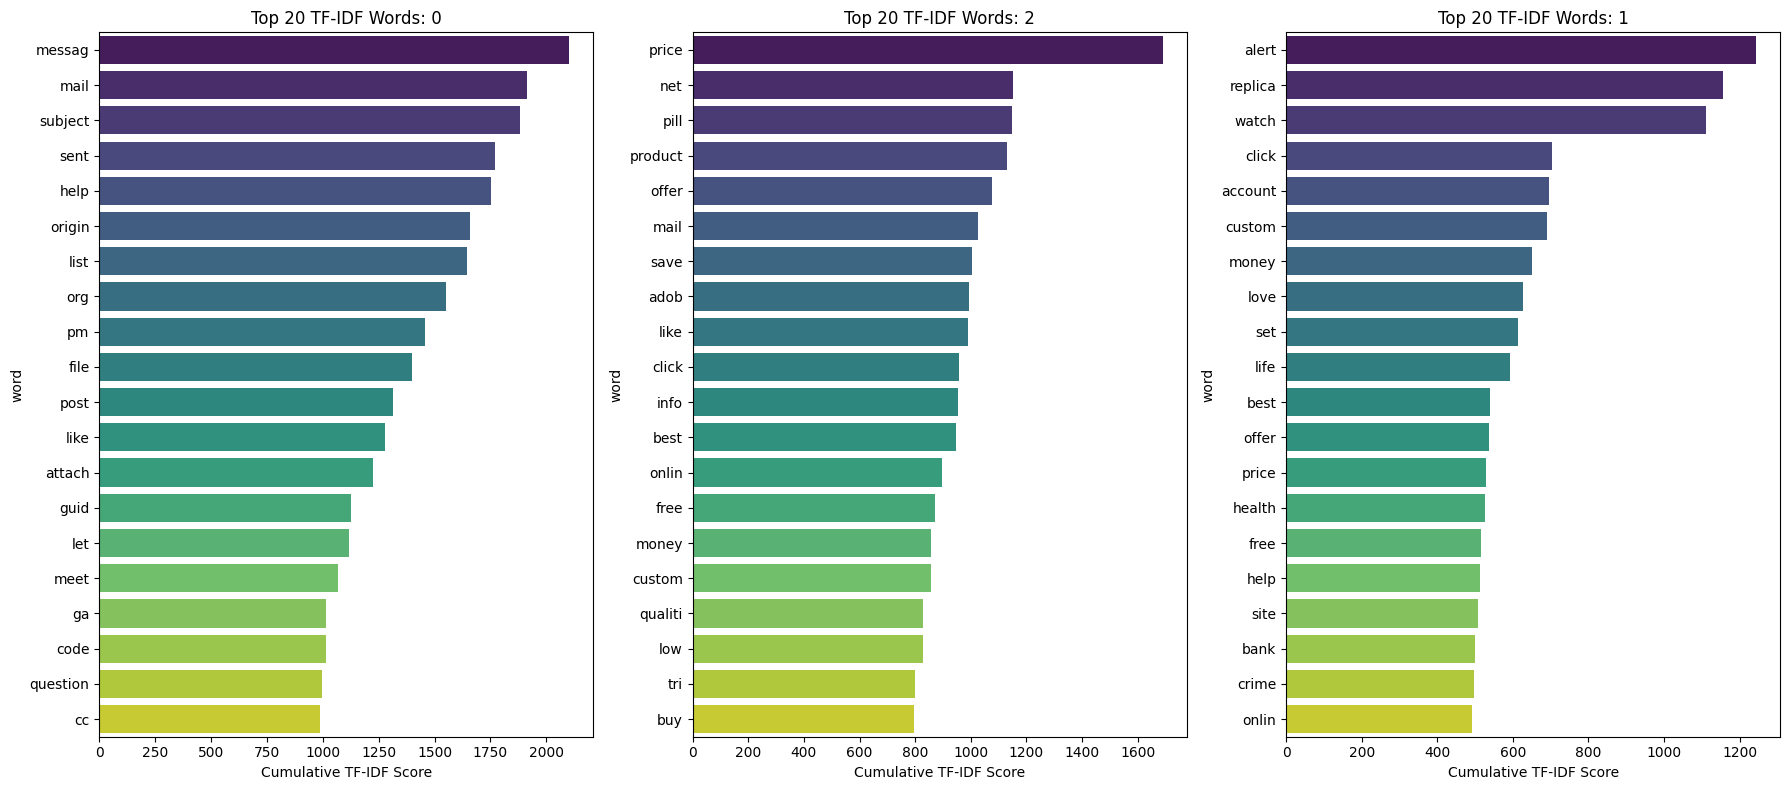

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# setup for table
summary = df.groupby('label')['word_count'].agg(['count', 'mean', 'median']).rename(
    columns={'count': 'Total Samples', 'mean': 'Avg Word Count', 'median': 'Median Word Count'}
)

# dictionary to store the vocabulary sizes we find during the loop
vocab_sizes = {}

# combined Loop for visualization and vocab counting
classes = df['label'].unique()
plt.figure(figsize=(18, 8))

# define the vectorizer for the visualization (with max_features to keep charts readable and min_df to avoid noise)
tfidf_viz = TfidfVectorizer(max_features=5000, stop_words='english', min_df=2)

# define a separate vectorizer for the summary table (no max_features to get the FULL vocab size and no min_df)
tfidf_full = TfidfVectorizer(stop_words='english')

for i, class_label in enumerate(classes):
    class_text = df[df['label'] == class_label]['cleaned_text']
    
    # skip if class is empty
    if class_text.str.strip().replace('', None).dropna().empty:
        vocab_sizes[class_label] = 0
        continue

    try:
        # --- PART A: CALCULATE FULL VOCABULARY SIZE ---
        tfidf_full.fit(class_text)
        vocab_sizes[class_label] = len(tfidf_full.vocabulary_)

        # --- PART B: GENERATE TF-IDF VISUALIZATION ---
        tfidf_matrix = tfidf_viz.fit_transform(class_text)
        sums = tfidf_matrix.sum(axis=0)
        
        data = []
        for col, idx in tfidf_viz.vocabulary_.items():
            data.append((col, sums[0, idx]))

        ranking = pd.DataFrame(data, columns=['word', 'tfidf_score'])
        ranking = ranking.sort_values('tfidf_score', ascending=False).head(20)

        #  plot
        plt.subplot(1, len(classes), i+1)
        sns.barplot(
            x='tfidf_score', 
            y='word', 
            data=ranking, 
            hue='word', 
            palette='viridis', 
            legend=False
        )
        plt.title(f'Top 20 TF-IDF Words: {class_label}')
        plt.xlabel('Cumulative TF-IDF Score')
        
    except ValueError as e:
        print(f"Could not process class '{class_label}': {e}")
        vocab_sizes[class_label] = 0

# finalize and display table
summary['Vocabulary Size'] = pd.Series(vocab_sizes)
print("\n--- Dataset Summary Statistics ---")
display(summary.round(2))

plt.tight_layout()
plt.show()

## Bigrams and Trigrams
Analyse small word sequences to understand context of removal, useful for posterior error analysis.

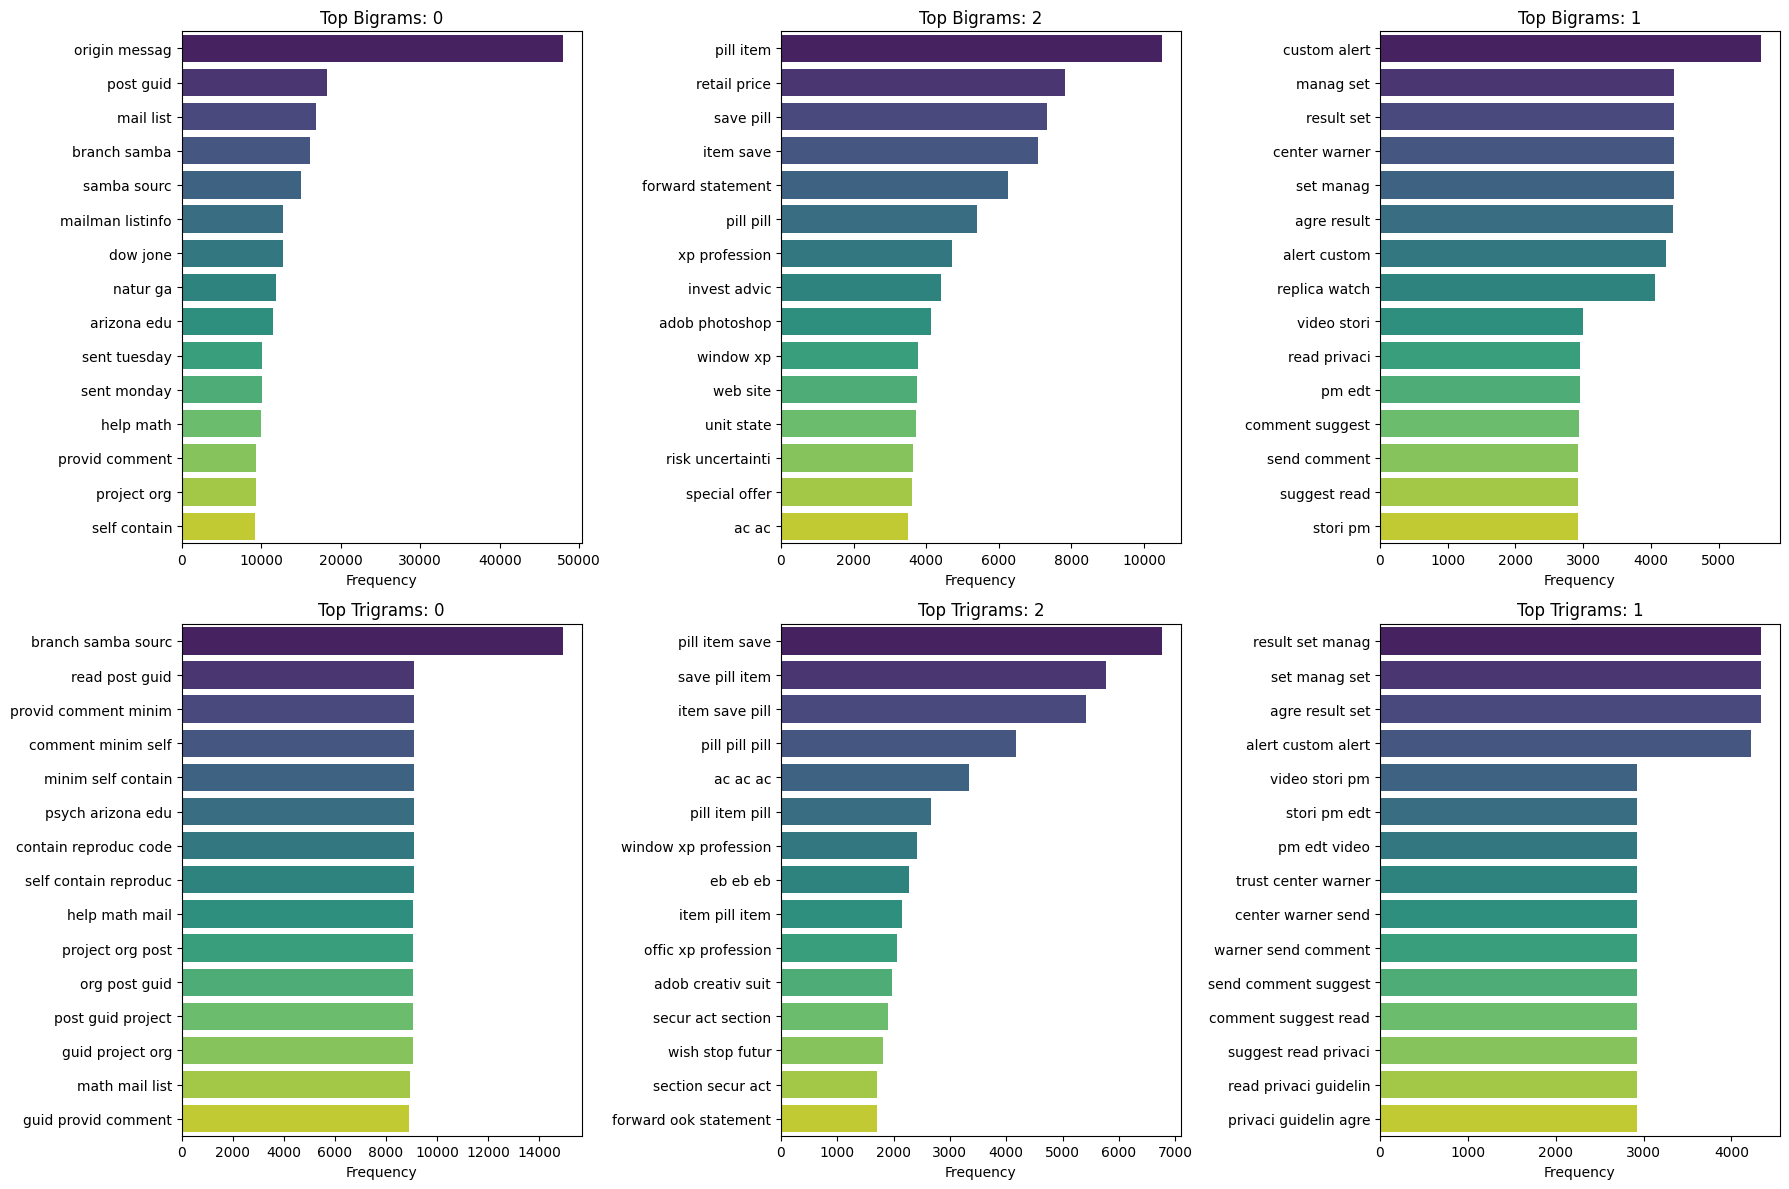

In [7]:
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import seaborn as sns

def plot_top_ngrams(corpus, title, n=2, top_n=15):
    # filter out empty or whitespace-only strings
    corpus = [doc for doc in corpus if str(doc).strip()]
    
    vec = CountVectorizer(ngram_range=(n, n), stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)[:top_n]
    
    words, counts = zip(*words_freq)
    
    sns.barplot(x=list(counts), y=list(words), hue=list(words), palette='viridis', legend=False)
    plt.title(title)
    plt.xlabel('Frequency')

# plotting Bigrams (n=2)
plt.figure(figsize=(18, 12))
classes = df['label'].unique()

for i, cls in enumerate(classes):
    plt.subplot(2, 3, i+1)
    plot_top_ngrams(df[df['label']==cls]['cleaned_text'], f'Top Bigrams: {cls}', n=2)

# plotting Trigrams (n=3)
for i, cls in enumerate(classes):
    plt.subplot(2, 3, i+4)
    plot_top_ngrams(df[df['label']==cls]['cleaned_text'], f'Top Trigrams: {cls}', n=3)

plt.tight_layout()
plt.show()

## Character-Level Features
Check for digits, special characters and urls. Sanity check to ensure correct pre-processing.

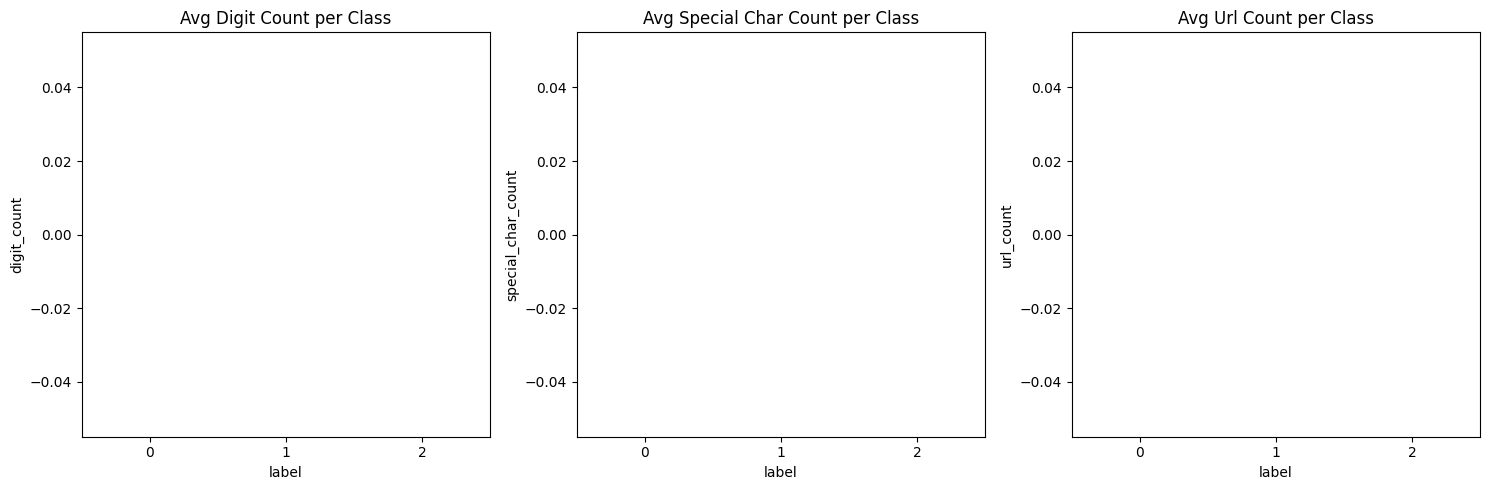

In [8]:
import re

# Function to count patterns
def get_char_features(text):
    text = str(text)
    return pd.Series({
        'digit_count': len(re.findall(r'\d', text)),
        'special_char_count': len(re.findall(r'[!$%&*@#]', text)),
        'url_count': len(re.findall(r'https?://\S+|www\.\S+', text)),
        'char_count': len(text)
    })

# Apply to the original text column (assuming it's called 'text')
char_features = df['cleaned_text'].apply(get_char_features)
df_with_chars = pd.concat([df, char_features], axis=1)

# Visualize averages per class
plt.figure(figsize=(15, 5))
feature_cols = ['digit_count', 'special_char_count', 'url_count']

for i, col in enumerate(feature_cols):
    plt.subplot(1, 3, i+1)
    sns.barplot(data=df_with_chars, x='label', y=col, palette='magma', hue='label', legend=False)
    plt.title(f'Avg {col.replace("_", " ").title()} per Class')

plt.tight_layout()
plt.show()

## Final WordCloud

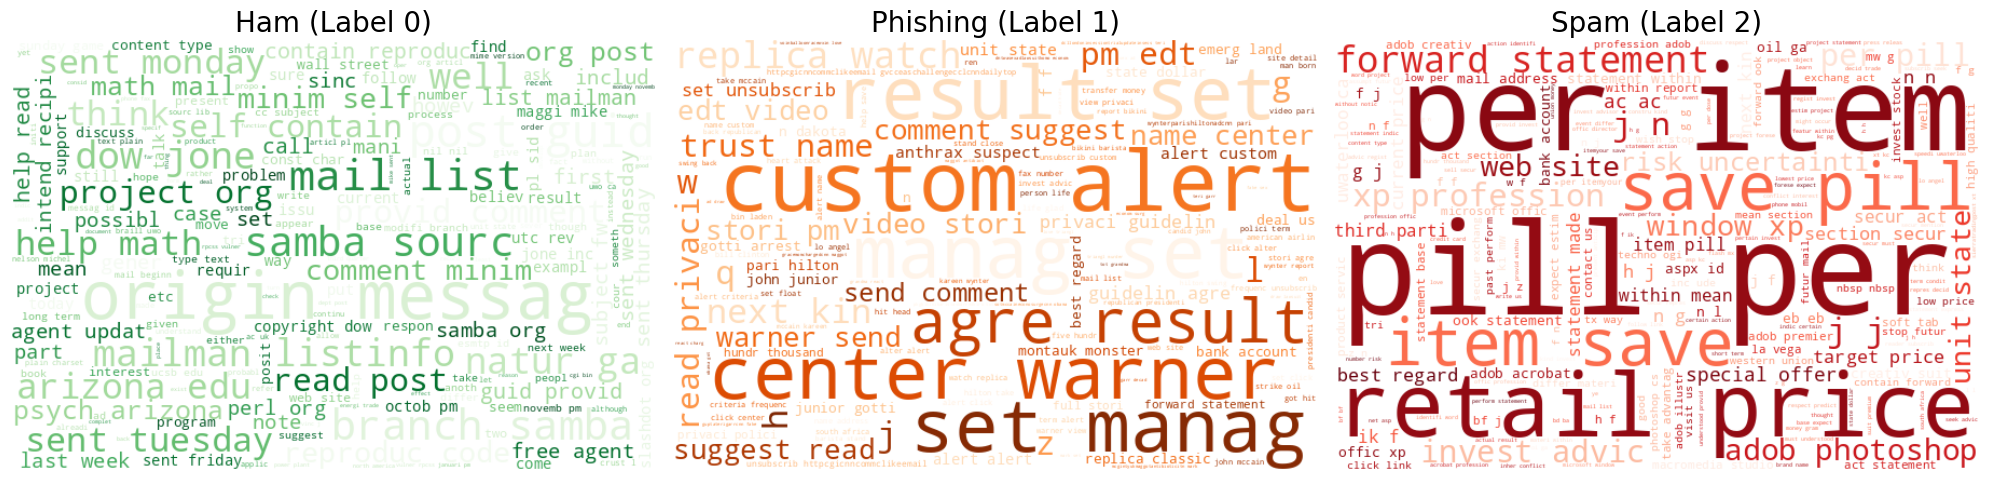

In [9]:
df_ham = df[df['label'] == 0]
df_phish = df[df['label'] == 1]
df_spam = df[df['label'] == 2]

ham_text = " ".join(df_ham['cleaned_text'].astype(str))
phish_text = " ".join(df_phish['cleaned_text'].astype(str))
spam_text = " ".join(df_spam['cleaned_text'].astype(str))

wc_ham = WordCloud(width=600, height=400, background_color='white', 
                   colormap='Greens').generate(ham_text)
wc_phish = WordCloud(width=600, height=400, background_color='white', 
                     colormap='Oranges').generate(phish_text)
wc_spam = WordCloud(width=600, height=400, background_color='white', 
                    colormap='Reds').generate(spam_text)

fig, axs = plt.subplots(1, 3, figsize=(20, 6))

axs[0].imshow(wc_ham, interpolation='bilinear')
axs[0].set_title('Ham (Label 0)', fontsize=20)
axs[0].axis('off')

axs[1].imshow(wc_phish, interpolation='bilinear')
axs[1].set_title('Phishing (Label 1)', fontsize=20)
axs[1].axis('off')

axs[2].imshow(wc_spam, interpolation='bilinear')
axs[2].set_title('Spam (Label 2)', fontsize=20)
axs[2].axis('off')

plt.tight_layout()
plt.show()